<a href="https://colab.research.google.com/github/pranavib433-glitch/ML-project/blob/main/fraud_detection_modeling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection
## Hybrid Logistic Regression + Isolation Forest

This notebook implements the modelling stage of the project (following the EDA in `eda.ipynb`):

1. Preprocessing (scaling, null check)
2. Class-imbalance handling (class-weighting)
3. Stratified train/test split
4. Model training — Logistic Regression (supervised) + Isolation Forest (unsupervised)
5. Hybrid score combining both models
6. Evaluation — Accuracy, Precision, Recall, F1-score, ROC-AUC

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")

1. Load the dataset

Works with either creditcard.csv (has a Time column) or creditcard_2023.csv (has an id column instead) — change the path below to whichever file you're using.

In [4]:
df = pd.read_csv('creditcard (1) (1) (1).csv')   # the 284,807-row imbalanced dataset (0.17% fraud)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())

df.head()

Dataset loaded successfully!
Rows: 211990
Columns: 31
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
print("Missing values per column:\n", df.isnull().sum().sum())

class_counts = df['Class'].value_counts()
print("\nClass balance:")
print(class_counts)
print((class_counts / len(df) * 100).round(3).astype(str) + ' %')


Missing values per column:
 21

Class balance:
Class
0.0    211595
1.0       394
Name: count, dtype: int64
Class
0.0    99.814 %
1.0     0.186 %
Name: count, dtype: object


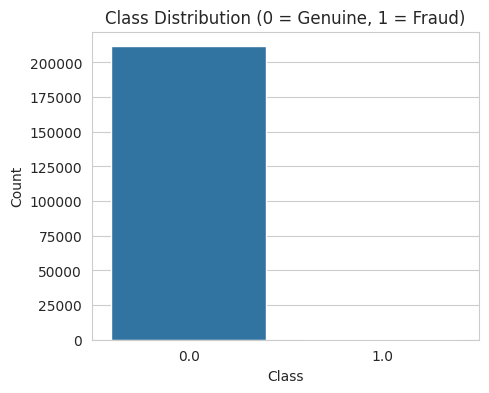

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Genuine, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

2. Preprocessing

Drop pure identifier columns (id, if present).
Scale Time and/or Amount with StandardScaler (the V1-V28 PCA components are already roughly standardized).
Split into X (features) and y (target).

In [9]:
data = df.copy()

# Remove unnecessary ID columns
for id_col in ('id', 'Unnamed: 0'):
    if id_col in data.columns:
        data = data.drop(columns=[id_col])

# Remove rows where Class is missing
data = data.dropna(subset=['Class'])

# Convert Class to integer
data['Class'] = data['Class'].astype(int)

# Scale Time and Amount
scaler = StandardScaler()

for col in ('Time', 'Amount'):
    if col in data.columns:
        data[col] = scaler.fit_transform(data[[col]])

# Separate features and target
X = data.drop(columns=['Class'])
y = data['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X.head()

X shape: (211989, 30)
y shape: (211989,)

Class distribution:
Class
0    211595
1       394
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-2.016392,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.239591
1,-2.016392,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.351897
2,-2.016365,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.161624
3,-2.016365,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.134441
4,-2.016338,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.080971


3. Stratified train/test split

Stratifying on Class keeps the fraud ratio identical in both the train and test sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print("Train fraud rate:", y_train.mean().round(4))
print("Test fraud rate: ", y_test.mean().round(4))

Train: 158,991 rows | Test: 52,998 rows
Train fraud rate: 0.0019
Test fraud rate:  0.0019


4. Model 1 — Logistic Regression (supervised)

class_weight='balanced' automatically re-weights the loss function to counter the class imbalance, without needing to resample the data (SMOTE could be swapped in here instead — see the note at the end).

In [11]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train, y_train)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)

5. Model 2 — Isolation Forest (unsupervised anomaly detection)

Isolation Forest is trained without labels — it isolates points that are easy to separate from the rest of the data (few random splits needed), which tend to correspond to anomalies/fraud. contamination is set to the observed fraud rate so the model knows roughly what fraction of points to flag.

In [12]:
contamination = max(y_train.mean(), 1e-4)

if_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
if_model.fit(X_train)

# IsolationForest.predict() -> -1 for anomaly (fraud), 1 for normal
if_raw_pred = if_model.predict(X_test)
if_pred = (if_raw_pred == -1).astype(int)

# decision_function: higher = more "normal" -> invert for an anomaly score
if_score = -if_model.decision_function(X_test)

6. Hybrid model
Combine both signals into a single fraud probability:

Logistic Regression probability P(fraud)
Isolation Forest anomaly score, min-max scaled to [0, 1]
lr_weight controls how much trust is placed in the supervised model vs. the anomaly detector.

In [13]:
def hybrid_predict(lr_proba, if_score, lr_weight=0.5, threshold=0.5):
    scaled_if = (if_score - if_score.min()) / (if_score.max() - if_score.min() + 1e-12)
    hybrid_score = lr_weight * lr_proba + (1 - lr_weight) * scaled_if
    hybrid_pred = (hybrid_score >= threshold).astype(int)
    return hybrid_score, hybrid_pred

hybrid_score, hybrid_pred = hybrid_predict(lr_proba, if_score, lr_weight=0.5)


7. Evaluation

Metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC — chosen (over plain accuracy alone) because they remain meaningful under severe class imbalance.

In [14]:
def evaluate(name, y_true, y_pred, y_score=None):
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_score)

    print(f"--- {name} ---")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k:<10}: {v:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Genuine', 'Fraud'], zero_division=0))
    return metrics

results = []
results.append(evaluate("Logistic Regression", y_test, lr_pred, lr_proba))
results.append(evaluate("Isolation Forest", y_test, if_pred, if_score))
results.append(evaluate("Hybrid (LR + Isolation Forest)", y_test, hybrid_pred, hybrid_score))

results_df = pd.DataFrame(results)
results_df

--- Logistic Regression ---
  Accuracy  : 0.9767
  Precision : 0.0715
  Recall    : 0.9596
  F1-score  : 0.1331
  ROC-AUC   : 0.9756
              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     52899
       Fraud       0.07      0.96      0.13        99

    accuracy                           0.98     52998
   macro avg       0.54      0.97      0.56     52998
weighted avg       1.00      0.98      0.99     52998

--- Isolation Forest ---
  Accuracy  : 0.9973
  Precision : 0.3070
  Recall    : 0.3535
  F1-score  : 0.3286
  ROC-AUC   : 0.9596
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     52899
       Fraud       0.31      0.35      0.33        99

    accuracy                           1.00     52998
   macro avg       0.65      0.68      0.66     52998
weighted avg       1.00      1.00      1.00     52998

--- Hybrid (LR + Isolation Forest) ---
  Accuracy  : 0.9859
  Precision : 0.1118
  

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.976659,0.071536,0.959596,0.133146,0.975566
1,Isolation Forest,0.997302,0.307018,0.353535,0.328638,0.959570
2,Hybrid (LR + Isolation Forest),0.985943,0.111779,0.939394,0.199785,0.987272


### Confusion matrices


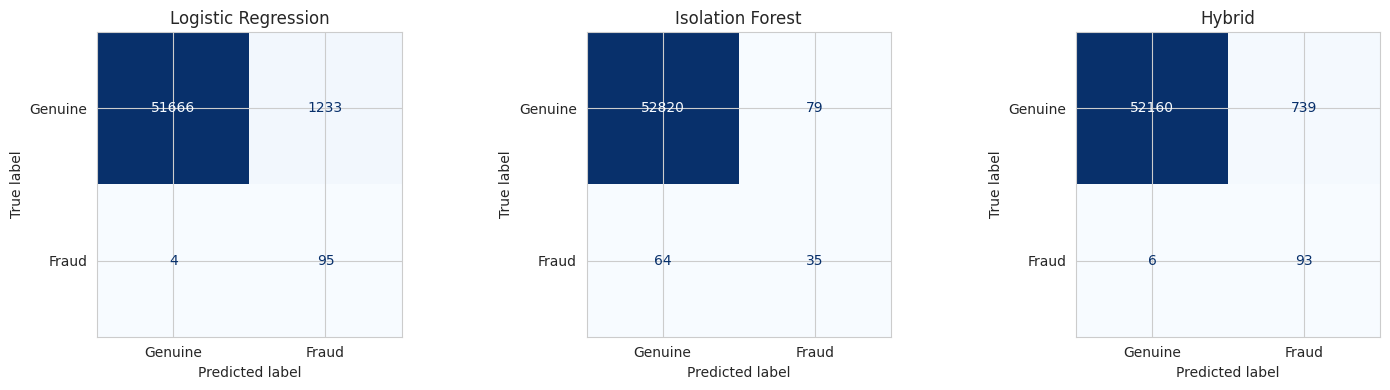

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(
    axes,
    [("Logistic Regression", lr_pred), ("Isolation Forest", if_pred), ("Hybrid", hybrid_pred)]
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Genuine', 'Fraud']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

ROC curves

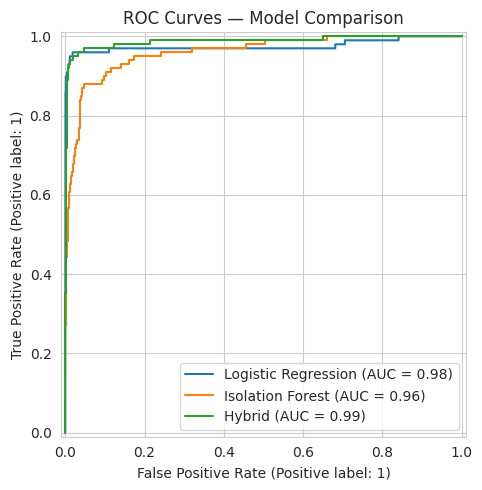

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, if_score, name="Isolation Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, hybrid_score, name="Hybrid", ax=ax)
ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()

Metric comparison bar chart

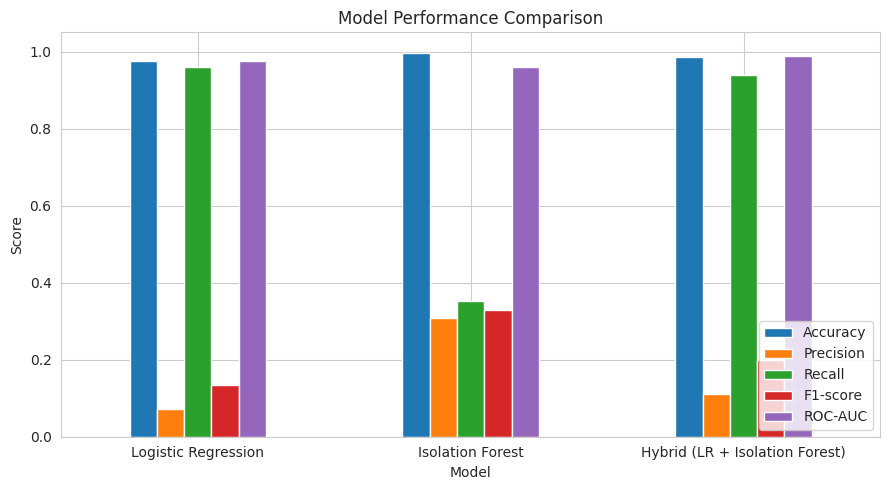

In [17]:
plot_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']]
ax = plot_df.plot(kind='bar', figsize=(9, 5), rot=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

8. (Optional) SMOTE instead of class-weighting
The methodology slide lists SMOTE as an alternative imbalance-handling strategy. To try it instead of class_weight='balanced', install imbalanced-learn and resample the training set only (never the test set):

# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_sm, y_train_sm)


Then re-run the evaluation cells on lr_smote and compare against the class-weighted version above.

## 9. Summary

- **Logistic Regression** uses the labelled data directly and typically gives the strongest overall metrics when fraud patterns resemble the training data.
- **Isolation Forest** needs no labels at all and is useful for catching novel fraud patterns that don't match anything seen during training, at the cost of noisier predictions.
- The **Hybrid** score blends both signals — tune `lr_weight` in Section 6 to favour one model over the other depending on how much you trust the labels vs. want protection against unseen fraud types.